In [1]:
!uv add tensorflow

Resolved 148 packages in 1ms
Checked 144 packages in 2ms


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow import keras

In [4]:
from tensorflow.keras.preprocessing.image import load_img

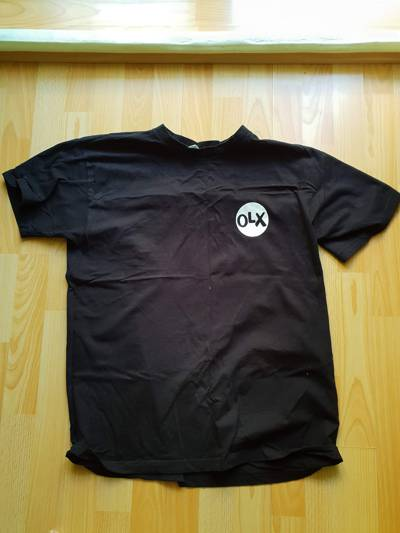

In [5]:
path = './clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [6]:
img = load_img(fullname, target_size=(299, 299))

In [7]:
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x7AF344DBEFC0>


In [8]:
x = np.array(img)
x.shape

(299, 299, 3)

In [9]:
from tensorflow.keras.applications.xception import  Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [10]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [11]:
X = np.array([x])
x.shape

(299, 299, 3)

In [12]:
X = preprocess_input(X)
X

array([[[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.41960788,  0.35686278, -0.20784312],
         ...,
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.99215686,  0.9372549 ]],

        [[ 0.47450984,  0.4039216 , -0.12156862],
         [ 0.4666667 ,  0.39607847, -0.12941176],
         [ 0.45882356,  0.38823533, -0.15294117],
         ...,
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.92941177]],

        [[ 0.56078434,  0.48235297, -0.00392157],
         [ 0.5686275 ,  0.4901961 ,  0.00392163],
         [ 0.5686275 ,  0.49803925, -0.01176471],
         ...,
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863]],

        ...,

        [[ 0.2941177 ,  0.18431377, -0

In [13]:
pred = model.predict(X)
pred.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


(1, 1000)

In [14]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

## 8.5 Transfer learning

* Reading data with `ImageDataGenerator`
* Train `Xception` on smaller images (150x150)

(Better to run it with a GPU)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train/',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [17]:
X, y = next(train_ds)

In [18]:
X.shape, y.shape

((32, 150, 150, 3), (32, 10))

In [19]:
y[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)

In [20]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [21]:
!ls -l clothing-dataset-small/train/

total 256
drwxr-xr-x 2 root root 20480 Jul 30 06:30 dress
drwxr-xr-x 2 root root 12288 Jul 30 06:30 hat
drwxr-xr-x 2 root root 36864 Jul 30 06:30 longsleeve
drwxr-xr-x 2 root root 20480 Jul 30 06:30 outwear
drwxr-xr-x 2 root root 32768 Jul 30 06:30 pants
drwxr-xr-x 2 root root 24576 Jul 30 06:30 shirt
drwxr-xr-x 2 root root 20480 Jul 30 06:30 shoes
drwxr-xr-x 2 root root 20480 Jul 30 06:30 shorts
drwxr-xr-x 2 root root 12288 Jul 30 06:30 skirt
drwxr-xr-x 2 root root 61440 Jul 30 06:30 t-shirt


In [22]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation/',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [23]:
base_model = Xception(
    weights='imagenet',
    input_shape=(150, 150, 3),
    include_top=False
)

base_model.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [24]:
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [25]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


In [26]:
preds.shape

(32, 10)

In [27]:
preds[0]

array([ 0.13668483,  0.26585686, -0.0513819 ,  0.07531525,  0.9236101 ,
       -0.03905844,  0.7854988 , -0.37944663,  0.49071217, -0.5446747 ],
      dtype=float32)

In [28]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

In [29]:
model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [30]:
!nvidia-smi

Thu Jul 30 06:32:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             33W /   70W |   13883MiB /  15360MiB |     25%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [31]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 50s 436ms/step - accuracy: 0.6656 - loss: 1.2509 - val_accuracy: 0.7742 - val_loss: 0.8568
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.8246 - loss: 0.5643 - val_accuracy: 0.7390 - val_loss: 0.9812
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8748 - loss: 0.3900 - val_accuracy: 0.7947 - val_loss: 0.9038
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9143 - loss: 0.2514 - val_accuracy: 0.7889 - val_loss: 0.9326
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9169 - loss: 0.2293 - val_accuracy: 0.7830 - val_loss: 1.0003
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9482 - loss: 0.1520 - val_accuracy: 0.7889 - val_loss: 1.0569
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9628 - loss: 0.1097 - val_accuracy: 0.8035 - val_loss: 0.9420
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9840 - loss: 0.0523 - val_accuracy: 0.8094 -

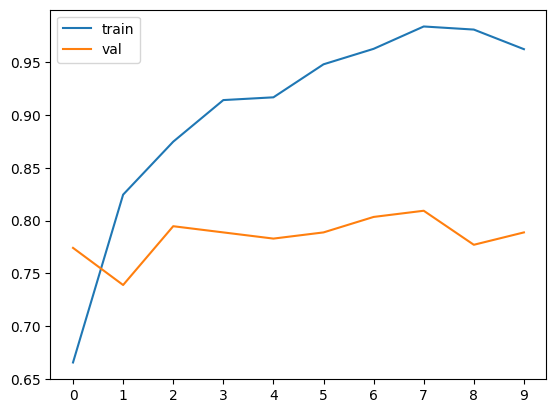

In [32]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()

In [33]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [34]:
tf.test.is_built_with_cuda()

True

In [35]:
def make_model(learning_rate=0.01):
  base_model = Xception(
    weights='imagenet',
    input_shape=(150, 150, 3),
    include_top=False
)

  base_model.trainable = False

  ####################################################

  inputs = keras.Input(shape=(150, 150, 3))
  base = base_model(inputs)
  vectors = keras.layers.GlobalAveragePooling2D()(base)
  outputs = keras.layers.Dense(10)(vectors)
  model = keras.Model(inputs, outputs)

  ####################################################
  optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  loss = keras.losses.CategoricalCrossentropy(from_logits=True)

  model.compile(
      optimizer=optimizer,
      loss=loss,
      metrics=['accuracy']
  )

  return model

In [36]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
  print(f'learning rate = {lr}')
  model = make_model(lr)
  history = model.fit(train_ds, epochs=10, validation_data=val_ds)
  scores[lr] = history.history

  print('##############')

learning rate = 0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 0.2836 - loss: 2.0948 - val_accuracy: 0.4252 - val_loss: 1.7075
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.5420 - loss: 1.4502 - val_accuracy: 0.5630 - val_loss: 1.3174
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.6392 - loss: 1.1735 - val_accuracy: 0.6276 - val_loss: 1.1138
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.6835 - loss: 1.0222 - val_accuracy: 0.6921 - val_loss: 0.9951
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.7096 - loss: 0.9242 - val_accuracy: 0.7331 - val_loss: 0.9160
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.7304 - loss: 0.8537 - val_accuracy: 0.7390 - val_loss: 0.8599
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.7471 - loss: 0.7993 - val_accuracy: 0.7625 - val_loss: 0.8155
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.7598 - loss: 0.7558

In [37]:
del scores[0.0001]
del scores[0.1]

0.001 {'accuracy': [0.6316818594932556, 0.7930247783660889, 0.8337679505348206, 0.8634289503097534, 0.8829856514930725, 0.9090612530708313, 0.9220991134643555, 0.9351369142532349, 0.9432855248451233, 0.9485006332397461], 'loss': [1.094560980796814, 0.6260636448860168, 0.5032033920288086, 0.4314553737640381, 0.3712151050567627, 0.32264596223831177, 0.28712764382362366, 0.2586982548236847, 0.23005187511444092, 0.21432191133499146], 'val_accuracy': [0.7771260738372803, 0.803519070148468, 0.8211143612861633, 0.803519070148468, 0.8269794583320618, 0.8240469098091125, 0.8328445553779602, 0.8152492642402649, 0.8211143612861633, 0.8181818127632141], 'val_loss': [0.721526026725769, 0.6152310371398926, 0.5944739580154419, 0.5893246531486511, 0.5687896013259888, 0.5540238618850708, 0.5530297756195068, 0.55704265832901, 0.5528478622436523, 0.5556878447532654]}
0.01 {'accuracy': [0.678943932056427, 0.8282268643379211, 0.8676662445068359, 0.9093872308731079, 0.9400261044502258, 0.9732725024223328, 0

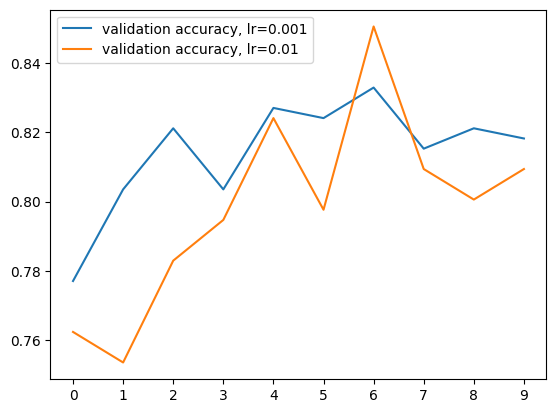

In [38]:
for lr, hist in scores.items():
  print(lr, hist)
  plt.plot(hist['val_accuracy'], label=f'validation accuracy, lr={lr}')
  # plt.plot(hist['accuracy'], label=f'training accuracy, lr={lr}')

plt.xticks(np.arange(10))
plt.legend()

In [39]:
model.save_weights('model_v1.weights.h5')

In [40]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [41]:
learning_rate = 0.001

model = make_model(learning_rate)
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]
  )

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4957 - loss: 1.5377

96/96 ━━━━━━━━━━━━━━━━━━━━ 34s 226ms/step - accuracy: 0.6248 - loss: 1.1311 - val_accuracy: 0.7742 - val_loss: 0.7378
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7757 - loss: 0.6549

96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.7836 - loss: 0.6381 - val_accuracy: 0.7830 - val_loss: 0.6461
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8335 - loss: 0.5041

96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.8266 - loss: 0.5120 - val_accuracy: 0.7889 - val_loss: 0.6245
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8560 - loss: 0.4362

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.8569 - loss: 0.4348 - val_accuracy: 0.8123 - val_loss: 0.5769
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8776 - loss: 0.3839

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8820 - loss: 0.3727 - val_accuracy: 0.8152 - val_loss: 0.5734
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.9068 - loss: 0.3321 - val_accuracy: 0.8035 - val_loss: 0.5666
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9159 - loss: 0.2970 - val_accuracy: 0.8065 - val_loss: 0.5679
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9283 - loss: 0.2644 - val_accuracy: 0.8123 - val_loss: 0.5605
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9472 - loss: 0.2337 - val_accuracy: 0.8152 - val_loss: 0.5356
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9524 - loss: 0.2117 - val_accuracy: 0.8152 - val_loss: 0.5410


In [42]:
def make_model(learning_rate=0.01, size_inner=100):
  base_model = Xception(
    weights='imagenet',
    input_shape=(150, 150, 3),
    include_top=False
)

  base_model.trainable = False

  ####################################################

  inputs = keras.Input(shape=(150, 150, 3))
  base = base_model(inputs)
  vectors = keras.layers.GlobalAveragePooling2D()(base)
  inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
  outputs = keras.layers.Dense(10)(inner)
  model = keras.Model(inputs, outputs)

  ####################################################
  optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  loss = keras.losses.CategoricalCrossentropy(from_logits=True)

  model.compile(
      optimizer=optimizer,
      loss=loss,
      metrics=['accuracy']
  )

  return model

In [43]:
learning_rate = 0.001

scores = {}

for size_inner in [10, 100, 1000]:
  print(f'size inner = {size_inner}')
  model = make_model(learning_rate, size_inner=size_inner)
  history = model.fit(train_ds, epochs=10, validation_data=val_ds)
  scores[size_inner] = history.history

  print('##############')

size inner = 10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 225ms/step - accuracy: 0.4342 - loss: 1.6700 - val_accuracy: 0.5073 - val_loss: 1.3871
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.5802 - loss: 1.2119 - val_accuracy: 0.5953 - val_loss: 1.1242
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.6838 - loss: 0.9531 - val_accuracy: 0.6979 - val_loss: 0.8938
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.7480 - loss: 0.7377 - val_accuracy: 0.7449 - val_loss: 0.7769
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.7947 - loss: 0.6069 - val_accuracy: 0.7537 - val_loss: 0.6860
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8263 - loss: 0.5311 - val_accuracy: 0.7537 - val_loss: 0.6937
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8507 - loss: 0.4668 - val_accuracy: 0.7918 - val_loss: 0.6399
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.8768 - loss: 0.4152 - val_a

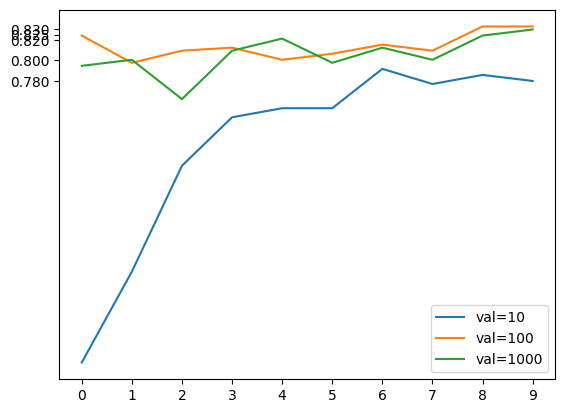

In [44]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83])
plt.legend()

In [45]:
def make_model(learning_rate=0.01, size_inner=100, drop_rate=0.5):
  base_model = Xception(
    weights='imagenet',
    input_shape=(150, 150, 3),
    include_top=False
)

  base_model.trainable = False

  ####################################################

  inputs = keras.Input(shape=(150, 150, 3))
  base = base_model(inputs)
  vectors = keras.layers.GlobalAveragePooling2D()(base)
  inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
  drop = keras.layers.Dropout(drop_rate)(inner)
  outputs = keras.layers.Dense(10)(drop)
  model = keras.Model(inputs, outputs)

  ####################################################
  optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  loss = keras.losses.CategoricalCrossentropy(from_logits=True)

  model.compile(
      optimizer=optimizer,
      loss=loss,
      metrics=['accuracy']
  )

  return model

In [46]:
learning_rate = 0.001
size_inner = 100

scores = {}

for drop_rate in [0.0, 0.2, 0.5, 0.8]:
  print(f'drop rate = {drop_rate}')
  model = make_model(learning_rate, size_inner=size_inner, drop_rate=drop_rate)
  history = model.fit(train_ds, epochs=30, validation_data=val_ds)
  scores[drop_rate] = history.history

  print('##############')

drop rate = 0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 215ms/step - accuracy: 0.6701 - loss: 0.9643 - val_accuracy: 0.7419 - val_loss: 0.7291
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.8142 - loss: 0.5247 - val_accuracy: 0.8152 - val_loss: 0.5758
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8862 - loss: 0.3561 - val_accuracy: 0.8358 - val_loss: 0.5609
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9224 - loss: 0.2513 - val_accuracy: 0.8182 - val_loss: 0.5428
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9475 - loss: 0.1907 - val_accuracy: 0.8152 - val_loss: 0.6003
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9697 - loss: 0.1263 - val_accuracy: 0.8211 - val_loss: 0.5358
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9853 - loss: 0.0852 - val_accuracy: 0.8182 - val_loss: 0.5700
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9935 - loss: 0.0626 - val_ac

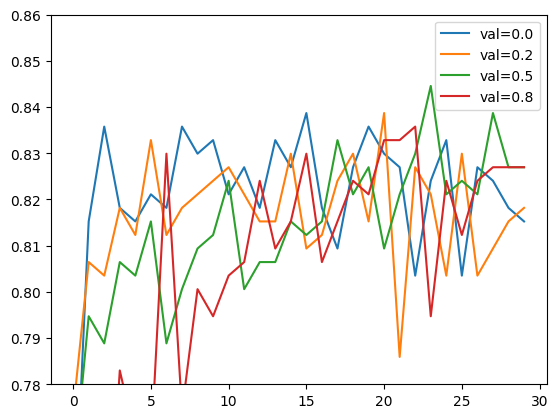

In [47]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

plt.ylim(0.78, 0.86)
plt.legend()

In [51]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    # rotation_range=30,
    # width_shift_range=10,
    # height_shift_range=10,
    shear_range=10,
    zoom_range=0.1,
    # horizontal_flip=True,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train/',
    target_size=(150, 150),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/train/',
    target_size=(150, 150),
    batch_size=32
)


Found 3068 images belonging to 10 classes.
Found 3068 images belonging to 10 classes.


In [52]:
learning_rate = 0.001
size_inner = 100
drop_rate = 0.2

model = make_model(learning_rate, size_inner=size_inner, drop_rate=drop_rate)
history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 53s 457ms/step - accuracy: 0.5554 - loss: 1.3119 - val_accuracy: 0.7500 - val_loss: 0.7421
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 313ms/step - accuracy: 0.6877 - loss: 0.9000 - val_accuracy: 0.7947 - val_loss: 0.5987
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 315ms/step - accuracy: 0.7373 - loss: 0.7739 - val_accuracy: 0.8220 - val_loss: 0.5285
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 315ms/step - accuracy: 0.7490 - loss: 0.7311 - val_accuracy: 0.8282 - val_loss: 0.4861
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 324ms/step - accuracy: 0.7696 - loss: 0.6547 - val_accuracy: 0.8514 - val_loss: 0.4442
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 324ms/step - accuracy: 0.7966 - loss: 0.5960 - val_accuracy: 0.8722 - val_loss: 0.3784
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 339ms/step - accuracy: 0.8008 - loss: 0.5701 - val_accuracy: 0.8709 - val_loss: 0.3936
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 346ms/step - accuracy: 0.8129 - loss: 0.5315 - val_accu

KeyboardInterrupt: 

In [ ]:
hist = history.history
plt.plot(hist['val_accuracy'], label='val')
plt.plot(hist['accuracy'], label='train')

plt.legend()

In [53]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [54]:
input_size = 299

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=10,
    height_shift_range=10,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train/',
    target_size=(input_size, input_size),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/train/',
    target_size=(input_size, input_size),
    batch_size=32
)

Found 3068 images belonging to 10 classes.
Found 3068 images belonging to 10 classes.


In [55]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [ ]:
learning_rate = 0.0005
size = 100
droprate = 0.2

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.4509 - loss: 1.6934

96/96 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.5665 - loss: 1.3529 - val_accuracy: 0.7904 - val_loss: 0.6618
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.6921 - loss: 0.9396

96/96 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7037 - loss: 0.8889 - val_accuracy: 0.8295 - val_loss: 0.5250
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.7364 - loss: 0.7998

96/96 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7471 - loss: 0.7711 - val_accuracy: 0.8468 - val_loss: 0.4545
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.7587 - loss: 0.7117

96/96 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7643 - loss: 0.7009 - val_accuracy: 0.8585 - val_loss: 0.4094
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.7842 - loss: 0.6448

96/96 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7862 - loss: 0.6399 - val_accuracy: 0.8703 - val_loss: 0.3981
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.8096 - loss: 0.6053

96/96 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7992 - loss: 0.6092 - val_accuracy: 0.8810 - val_loss: 0.3522
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8044 - loss: 0.5946

96/96 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.7999 - loss: 0.5930 - val_accuracy: 0.8895 - val_loss: 0.3361
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8116 - loss: 0.5525 - val_accuracy: 0.8882 - val_loss: 0.3247
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8152 - loss: 0.5317 - val_accuracy: 0.8882 - val_loss: 0.3139
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.8209 - loss: 0.5399

96/96 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8289 - loss: 0.5213 - val_accuracy: 0.8934 - val_loss: 0.3252
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8401 - loss: 0.4931

96/96 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8357 - loss: 0.4956 - val_accuracy: 0.8993 - val_loss: 0.2925
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.8383 - loss: 0.4747

## 8.12 Using the model

* Loading the model
* Evaluating the model
* Getting predictions

In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.applications.xception import preprocess_input

In [3]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './clothing-dataset-small/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)

Found 372 images belonging to 10 classes.


In [5]:
model = keras.models.load_model('xception_v4_1_14_0.909.h5')

In [6]:
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8602 - loss: 0.3460


[0.3459734320640564, 0.8602150678634644]

In [7]:
path = 'clothing-dataset-small/test/pants/c8d21106-bbdb-4e8d-83e4-bf3d14e54c16.jpg'

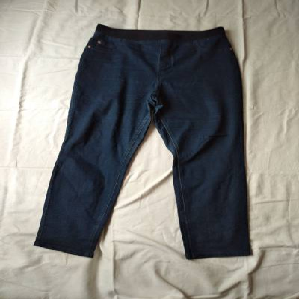

In [15]:
img = load_img(path, target_size=(299, 299))
img

In [9]:
import numpy as np

In [10]:
x = np.array(img)
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [11]:
X = preprocess_input(X)

In [12]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step


In [13]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [14]:
dict(zip(classes, pred[0]))

{'dress': np.float32(-2.3643572),
 'hat': np.float32(-5.3932695),
 'longsleeve': np.float32(0.51259774),
 'outwear': np.float32(-0.9939649),
 'pants': np.float32(8.766848),
 'shirt': np.float32(-1.6790373),
 'shoes': np.float32(-4.778157),
 'shorts': np.float32(3.291373),
 'skirt': np.float32(-2.832269),
 't-shirt': np.float32(-4.434716)}